## Optimización Bajo Incertidumbre (IIND 4125)

### Proyecto 2: Programación Estocástica

#### Daniel Velandia, Juan Aguirre y Sofía Acosta

In [1]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [2]:
# Parámetros principales del modelo
SEED_BASE = 123
INSTANCE = 1
DELTA_U = 0.8 # incremento de capacidad si se refuerza una línea
H_VALUE = 50 # costo de reforzar cada arco
BUDGET = 2500 # presupuesto total
PI = 190 # penalización por energía no servida
ALPHA = 0.95 # nivel CVaR

## 1. Generación de escenarios

In [3]:
# Carga de la red base

def load_edges_from_csv(path_edges: str):
    edges = pd.read_csv(path_edges)
    edges = edges.rename(columns={
        "node_id1": "i",
        "node_id2": "j",
        "b": "c_base",
        "f_max": "U_base"
    })
    edges["e_id"] = np.arange(len(edges))
    return edges

def load_nodes_from_csv(path_nodes: str):
    nodes = pd.read_csv(path_nodes)
    nodes = nodes.rename(columns={"node_id": "node"})
    return nodes

edges = load_edges_from_csv("edges.csv")
nodes = load_nodes_from_csv("nodes.csv")

nodes = nodes[nodes["instance"] == INSTANCE].reset_index(drop=True)

#print("Instancia:", INSTANCE)
print("Nodos:", len(nodes))
print("Arcos:", len(edges))
print("Generadores:", nodes["is_generator"].sum())

Nodos: 118
Arcos: 179
Generadores: 18


In [4]:
def build_base_data(nodes, edges):
    nodes_list = nodes["node"].unique().tolist()
    edges_list = edges["e_id"].unique().tolist()

    demand_nodes = nodes[nodes["d"].fillna(0) > 0]["node"].tolist()
    gen_nodes = nodes[nodes["is_generator"] == True]["node"].tolist()

    out_arcs = {
        i: edges[edges["i"] == i]["e_id"].tolist()
        for i in nodes_list
    }

    in_arcs = {
        i: edges[edges["j"] == i]["e_id"].tolist()
        for i in nodes_list
    }

    arc_i = dict(zip(edges["e_id"], edges["i"]))
    arc_j = dict(zip(edges["e_id"], edges["j"]))

    U_base = dict(zip(edges["e_id"], edges["U_base"]))
    H_e = {e: H_VALUE for e in edges_list}

    return {
        "nodes_list": nodes_list,
        "edges_list": edges_list,
        "demand_nodes": demand_nodes,
        "gen_nodes": gen_nodes,
        "in_arcs": in_arcs,
        "out_arcs": out_arcs,
        "arc_i": arc_i,
        "arc_j": arc_j,
        "U_base": U_base,
        "H_e": H_e
    }


base = build_base_data(nodes, edges)

print("Nodos de demanda:", len(base["demand_nodes"]))
print("Nodos generadores:", len(base["gen_nodes"]))
print("Arcos:", len(base["edges_list"]))

Nodos de demanda: 89
Nodos generadores: 18
Arcos: 179


In [5]:
# Generador de escenarios
def sample_one_scenario_W(
    nodes, edges, rng,
    p_crisis=0.15,
    dem_sigma=0.10,
    cost_sigma=0.05,
    p_outage=0.20,
    cap_drop=0.45,
    crisis_cost_mult=1.25,
    correlated_outage_nodes=None,
    correlated_outage_prob=0.80
):
    crisis = rng.random() < p_crisis

    # -----------------------------
    # Demanda
    # -----------------------------
    D = nodes[["node"]].copy()
    D["D_base"] = nodes["d"].fillna(0.0)

    if not crisis:
        mult = rng.normal(1.0, dem_sigma, size=len(D))
        mult = np.clip(mult, 0.0, None)
    else:
        pareto_alpha = 2.0
        mult = 1.0 + rng.pareto(a=pareto_alpha, size=len(D))

    D["D_w"] = D["D_base"] * mult
    D.loc[D["D_base"] == 0, "D_w"] = 0.0

    # -----------------------------
    # Costos operativos
    # -----------------------------
    c = edges[["e_id", "c_base"]].copy()

    if not crisis:
        cost_mult = rng.normal(1.0, cost_sigma, size=len(c))
        cost_mult = np.clip(cost_mult, 0.1, None)
    else:
        cost_mult = np.ones(len(c)) * crisis_cost_mult

    c["c_w"] = c["c_base"] * cost_mult

    # -----------------------------
    # Capacidad efectiva
    # -----------------------------
    U = edges[["e_id", "i", "j", "U_base"]].copy()
    U["U_w"] = U["U_base"]

    outage = rng.random(len(U)) < p_outage
    U.loc[outage, "U_w"] = cap_drop * U.loc[outage, "U_base"]

    if crisis and correlated_outage_nodes is not None:
        for node in correlated_outage_nodes:
            if rng.random() < correlated_outage_prob:
                mask = (U["i"] == node) | (U["j"] == node)
                U.loc[mask, "U_w"] = 0.0

    # -----------------------------
    # Generación disponible
    # -----------------------------
    G = nodes[["node", "p_max", "is_generator"]].copy()
    G["G_w"] = np.where(G["is_generator"] == True, G["p_max"].fillna(0.0), 0.0)

    if crisis:
        G["G_w"] = 0.85 * G["G_w"]

    return {
        "D": D[["node", "D_w"]],
        "U": U[["e_id", "U_w"]],
        "c": c[["e_id", "c_w"]],
        "G": G[["node", "G_w"]],
        "crisis": crisis
    }

In [6]:
def generate_scenarios_table(nodes, edges, N, seed=123):
    rng = np.random.default_rng(seed)

    gen_nodes = nodes[nodes["is_generator"] == True]["node"].tolist()

    scenarios = []
    for _ in range(N):
        sc = sample_one_scenario_W(
            nodes,
            edges,
            rng,
            correlated_outage_nodes=gen_nodes
        )
        scenarios.append(sc)

    rows_D, rows_U, rows_c, rows_G, rows_p = [], [], [], [], []

    p = 1.0 / N

    for w, sc in enumerate(scenarios, start=1):
        rows_p.append({
            "omega": w,
            "p_omega": p,
            "crisis": sc["crisis"]
        })

        for _, r in sc["D"].iterrows():
            rows_D.append({
                "omega": w,
                "node": int(r["node"]),
                "D_iw": float(r["D_w"])
            })

        for _, r in sc["U"].iterrows():
            rows_U.append({
                "omega": w,
                "e_id": int(r["e_id"]),
                "U_ew": float(r["U_w"])
            })

        for _, r in sc["c"].iterrows():
            rows_c.append({
                "omega": w,
                "e_id": int(r["e_id"]),
                "c_ew": float(r["c_w"])
            })

        for _, r in sc["G"].iterrows():
            rows_G.append({
                "omega": w,
                "node": int(r["node"]),
                "G_iw": float(r["G_w"])
            })

    return (
        pd.DataFrame(rows_D),
        pd.DataFrame(rows_U),
        pd.DataFrame(rows_c),
        pd.DataFrame(rows_G),
        pd.DataFrame(rows_p)
    )

In [7]:
def build_scenario_data(dfD, dfU, dfc, dfG, dfp):
    omegas = dfp["omega"].tolist()

    p_omega = dict(zip(dfp["omega"], dfp["p_omega"]))

    D = {
        (int(r.omega), int(r.node)): float(r.D_iw)
        for _, r in dfD.iterrows()
    }

    U_ew = {
        (int(r.omega), int(r.e_id)): float(r.U_ew)
        for _, r in dfU.iterrows()
    }

    c_ew = {
        (int(r.omega), int(r.e_id)): float(r.c_ew)
        for _, r in dfc.iterrows()
    }

    G_iw = {
        (int(r.omega), int(r.node)): float(r.G_iw)
        for _, r in dfG.iterrows()
    }

    return omegas, p_omega, D, U_ew, c_ew, G_iw

In [8]:
# Prueba escenarios variando N
N_TEST = 10

dfD, dfU, dfc, dfG, dfp = generate_scenarios_table(
    nodes,
    edges,
    N=N_TEST,
    seed=SEED_BASE
)

omegas, p_omega, D, U_ew, c_ew, G_iw = build_scenario_data(
    dfD, dfU, dfc, dfG, dfp
)

print("Escenarios generados:", len(omegas))
print("Suma de probabilidades:", sum(p_omega.values()))
print("Escenarios de crisis:", dfp["crisis"].sum())

C:\Users\sofia\AppData\Local\Temp\ipykernel_46576\688715757.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[575.55 132.75 121.95 127.8  121.95 150.3  143.1   92.25 142.2  141.75
 128.7  121.95 121.5  113.4  136.8  113.4  150.3  142.2  556.2  150.3
 113.85 113.85 121.95 142.2  113.4  100.35 130.05 111.6  142.2  621.9 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  U.loc[outage, "U_w"] = cap_drop * U.loc[outage, "U_base"]
C:\Users\sofia\AppData\Local\Temp\ipykernel_46576\688715757.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[142.2  142.2  121.95 132.75 116.55 143.1  121.95 141.75 121.95  94.5
 122.85 121.5  136.8  125.55 113.4   90.45 240.3  142.2   58.05 113.85
 121.95 140.85 141.75 113.85 121.5  121.95 113.4  109.35 121.95 890.1
 615.6  642.15 113.85]' has dtype in

Escenarios generados: 10
Suma de probabilidades: 0.9999999999999999
Escenarios de crisis: 1


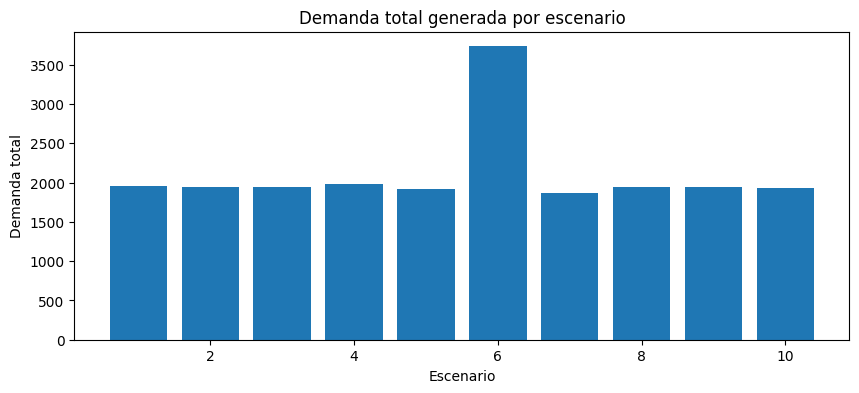

In [9]:
# Comparación de escenarios generados

# Demanda
demanda_total = dfD.groupby("omega")["D_iw"].sum().reset_index()
demanda_total = demanda_total.merge(dfp, on="omega")

plt.figure(figsize=(10,4))
plt.bar(demanda_total["omega"], demanda_total["D_iw"])
plt.title("Demanda total generada por escenario")
plt.xlabel("Escenario")
plt.ylabel("Demanda total")
plt.show()

<Figure size 600x400 with 0 Axes>

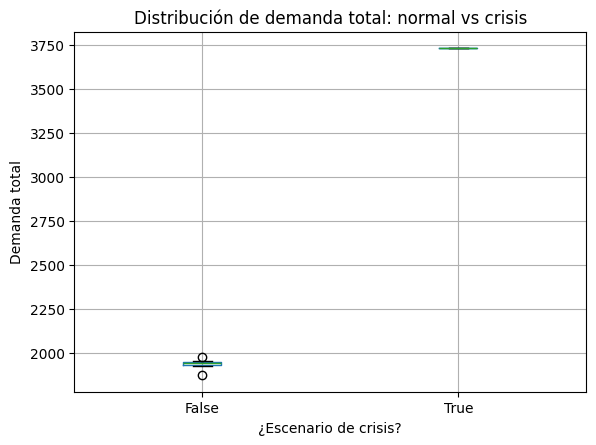

In [10]:
plt.figure(figsize=(6,4))
demanda_total.boxplot(column="D_iw", by="crisis")
plt.title("Distribución de demanda total: normal vs crisis")
plt.suptitle("")
plt.xlabel("¿Escenario de crisis?")
plt.ylabel("Demanda total")
plt.show()

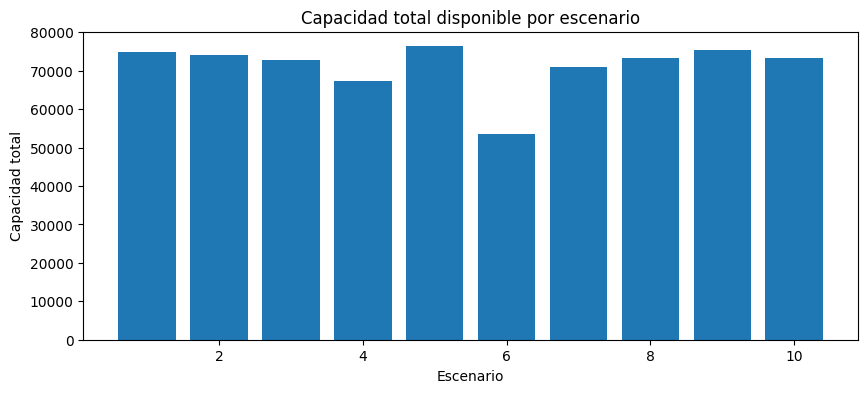

In [11]:
capacidad_total = dfU.groupby("omega")["U_ew"].sum().reset_index()
capacidad_total = capacidad_total.merge(dfp, on="omega")

plt.figure(figsize=(10,4))
plt.bar(capacidad_total["omega"], capacidad_total["U_ew"])
plt.title("Capacidad total disponible por escenario")
plt.xlabel("Escenario")
plt.ylabel("Capacidad total")
plt.show()

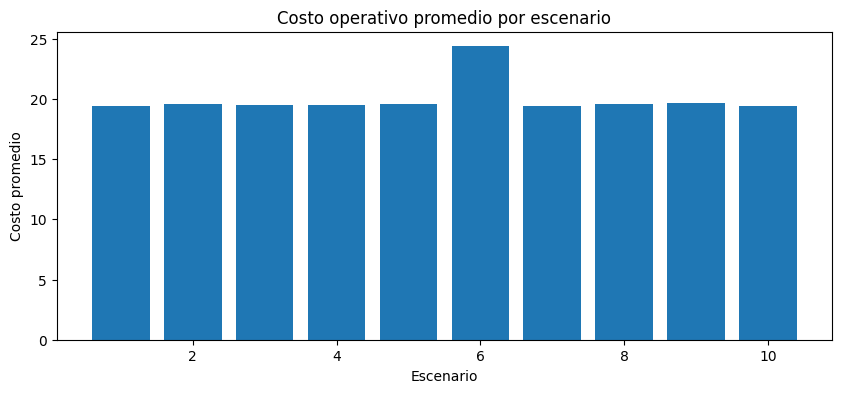

In [12]:
costo_promedio = dfc.groupby("omega")["c_ew"].mean().reset_index()
costo_promedio = costo_promedio.merge(dfp, on="omega")

plt.figure(figsize=(10,4))
plt.bar(costo_promedio["omega"], costo_promedio["c_ew"])
plt.title("Costo operativo promedio por escenario")
plt.xlabel("Escenario")
plt.ylabel("Costo promedio")
plt.show()

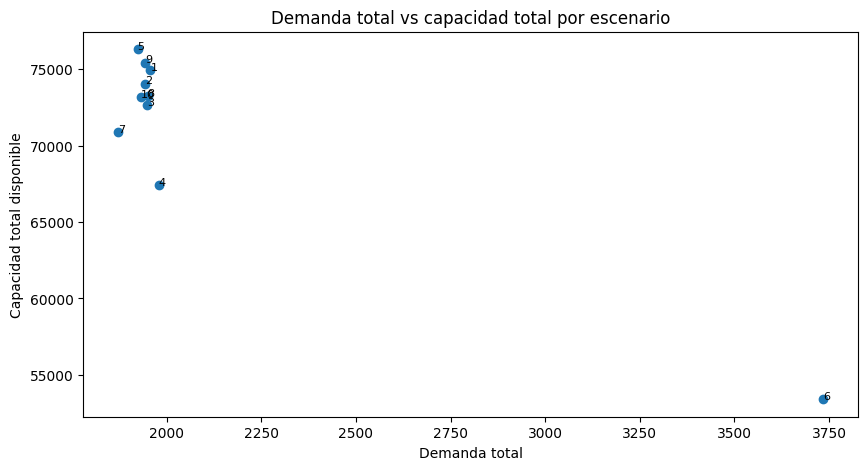

In [13]:
resumen = demanda_total[["omega", "D_iw", "crisis"]].merge(
    capacidad_total[["omega", "U_ew"]],
    on="omega"
)

plt.figure(figsize=(10,5))
plt.scatter(resumen["D_iw"], resumen["U_ew"])

for _, row in resumen.iterrows():
    plt.text(row["D_iw"], row["U_ew"], str(int(row["omega"])), fontsize=8)

plt.title("Demanda total vs capacidad total por escenario")
plt.xlabel("Demanda total")
plt.ylabel("Capacidad total disponible")
plt.show()

In [14]:
resumen["gap_demanda_capacidad"] = resumen["D_iw"] - resumen["U_ew"]

resumen.sort_values("gap_demanda_capacidad", ascending=False)

,omega,D_iw,crisis,U_ew,gap_demanda_capacidad
5,6,3733.559752,True,53403.80,-49670.240248
3,4,1978.934654,False,67427.15,-65448.215346
6,7,1872.883426,False,70885.55,-69012.666574
2,3,1949.060826,False,72647.75,-70698.689174
9,10,1932.285055,False,73167.50,-71235.214945
7,8,1950.122791,False,73246.15,-71296.027209
1,2,1943.299106,False,74054.10,-72110.800894
0,1,1957.299204,False,74929.70,-72972.400796
8,9,1943.138213,False,75422.50,-73479.361787
4,5,1923.418109,False,76316.25,-74392.831891


## 2. Componente algorítmico: tres estrategias de solución

En esta sección se comparan tres estrategias para resolver el mismo problema estocástico de dos etapas:

1. **Equivalente determinístico (DE):** resuelve la formulación extensiva completa en un solo modelo.
2. **Benders naive:** separa el problema en un master problem de primera etapa y subproblemas de segunda etapa por escenario.
3. **Branch-and-Cut con callbacks:** incorpora los cortes de Benders dentro del árbol de Branch & Bound de Gurobi usando lazy constraints.

El objetivo de esta comparación es analizar si las técnicas de descomposición permiten resolver el problema de forma más eficiente que la formulación extensiva.

## 2.1. Modelo equivalente determinístico

In [15]:
def solve_deterministic_equivalent(
    base,
    omegas,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw,
    delta_u=DELTA_U,
    budget=BUDGET,
    pi=PI,
    time_limit=None,
    verbose=True
):
    start = time.time()

    nodes_list = base["nodes_list"]
    edges_list = base["edges_list"]
    demand_nodes = base["demand_nodes"]
    gen_nodes = base["gen_nodes"]
    in_arcs = base["in_arcs"]
    out_arcs = base["out_arcs"]
    H_e = base["H_e"]

    m = gp.Model("Deterministic_Equivalent")

    if not verbose:
        m.Params.OutputFlag = 0

    if time_limit is not None:
        m.Params.TimeLimit = time_limit

    # Variables de primera etapa
    h = m.addVars(edges_list, vtype=GRB.BINARY, name="h")

    # Variables de segunda etapa
    f = m.addVars(omegas, edges_list, lb=0, name="f")
    delta = m.addVars(omegas, demand_nodes, lb=0, name="delta")
    g = m.addVars(omegas, gen_nodes, lb=0, name="g")

    # Presupuesto
    m.addConstr(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) <= budget,
        name="budget"
    )

    # Restricciones por escenario
    for w in omegas:

        # Capacidad de arcos
        for e in edges_list:
            m.addConstr(
                f[w, e] <= U_ew[w, e] * (1 + delta_u * h[e]),
                name=f"cap_w{w}_e{e}"
            )

        # Límite generación
        for i in gen_nodes:
            m.addConstr(
                g[w, i] <= G_iw[w, i],
                name=f"gen_w{w}_i{i}"
            )

        # Límite demanda no servida
        for i in demand_nodes:
            m.addConstr(
                delta[w, i] <= D[w, i],
                name=f"delta_w{w}_i{i}"
            )

        # Balance de flujo
        for i in nodes_list:

            inflow = gp.quicksum(f[w, e] for e in in_arcs[i])
            outflow = gp.quicksum(f[w, e] for e in out_arcs[i])

            if i in demand_nodes:
                m.addConstr(
                    inflow - outflow == D[w, i] - delta[w, i],
                    name=f"balance_demand_w{w}_i{i}"
                )

            elif i in gen_nodes:
                m.addConstr(
                    inflow - outflow == -g[w, i],
                    name=f"balance_gen_w{w}_i{i}"
                )

            else:
                m.addConstr(
                    inflow - outflow == 0,
                    name=f"balance_trans_w{w}_i{i}"
                )

    # Función objetivo
    investment_cost = gp.quicksum(H_e[e] * h[e] for e in edges_list)

    expected_operating_cost = gp.quicksum(
        p_omega[w] * gp.quicksum(c_ew[w, e] * f[w, e] for e in edges_list)
        for w in omegas
    )

    expected_ens_cost = gp.quicksum(
        p_omega[w] * pi * gp.quicksum(delta[w, i] for i in demand_nodes)
        for w in omegas
    )

    m.setObjective(
        investment_cost + expected_operating_cost + expected_ens_cost,
        GRB.MINIMIZE
    )

    m.optimize()

    runtime = time.time() - start

    if m.Status not in [GRB.OPTIMAL, GRB.TIME_LIMIT]:
        print("Estado del modelo:", m.Status)
        return None

    h_sol = {e: h[e].X for e in edges_list}

    selected_edges = [e for e in edges_list if h_sol[e] > 0.5]

    results = {
        "model": m,
        "objective": m.ObjVal,
        "runtime": runtime,
        "h_sol": h_sol,
        "selected_edges": selected_edges,
        "investment_cost": sum(H_e[e] * h_sol[e] for e in edges_list),
        "num_selected_edges": len(selected_edges)
    }

    return results

In [16]:

# Modelo con datos de prueba
de_results = solve_deterministic_equivalent(
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw,
    verbose=True
)

print("Objetivo DE:", de_results["objective"])
print("Tiempo:", de_results["runtime"])
print("Costo inversión:", de_results["investment_cost"])
print("Arcos reforzados:", de_results["num_selected_edges"])
print("Lista de arcos reforzados:", de_results["selected_edges"])

Set parameter Username
Set parameter LicenseID to value 2789937
Academic license - for non-commercial use only - expires 2027-03-10
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 5600U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 4041 rows, 3039 columns and 9425 nonzeros
Model fingerprint: 0x8bb5a572
Variable types: 2860 continuous, 179 integer (179 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+04]
  Objective range  [2e-01, 5e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+04]
Found heuristic solution: objective 402496.02159
Presolve removed 3208 rows and 1662 columns
Presolve time: 0.06s
Presolved: 833 rows, 1377 columns, 3438 nonzeros
Found heuristic solution: objective 336192.74450
Variable types: 1288 continuous, 89 integer (89 binary)
Found heuristic solution: objective 336170

In [17]:
edges_plot = edges.copy()
edges_plot["reforzado"] = edges_plot["e_id"].isin(de_results["selected_edges"])

edges_plot[["e_id", "i", "j", "U_base", "reforzado"]].sort_values(
    "reforzado",
    ascending=False
)

,e_id,i,j,U_base,reforzado
94,94,48,68,156,True
17,17,13,14,259,True
93,93,46,68,183,True
48,48,36,39,252,True
69,69,48,53,178,True
...,...,...,...,...,...
65,65,48,50,252,False
66,66,50,51,255,False
67,67,51,52,298,False
68,68,52,53,318,False


In [18]:
def extract_scenario_costs_from_de(de_results, base, omegas, p_omega, c_ew, pi=PI):
    m = de_results["model"]

    edges_list = base["edges_list"]
    demand_nodes = base["demand_nodes"]

    rows = []

    for w in omegas:
        op_cost = 0
        ens_cost = 0

        for e in edges_list:
            var = m.getVarByName(f"f[{w},{e}]")
            op_cost += c_ew[w, e] * var.X

        for i in demand_nodes:
            var = m.getVarByName(f"delta[{w},{i}]")
            ens_cost += pi * var.X

        rows.append({
            "omega": w,
            "p_omega": p_omega[w],
            "operating_cost": op_cost,
            "ens_cost": ens_cost,
            "second_stage_cost": op_cost + ens_cost
        })

    return pd.DataFrame(rows)


df_costs_de = extract_scenario_costs_from_de(
    de_results,
    base,
    omegas,
    p_omega,
    c_ew
)

df_costs_de

,omega,p_omega,operating_cost,ens_cost,second_stage_cost
0,1,0.1,62216.648053,66371.309477,128587.957531
1,2,0.1,62547.835965,71434.599035,133982.435000
2,3,0.1,65728.017988,72807.172739,138535.190727
3,4,0.1,65391.624186,77410.549294,142802.173480
4,5,0.1,61646.973188,70205.293030,131852.266218
5,6,0.1,57491.894944,553013.604155,610505.499100
6,7,0.1,61089.338110,71007.856089,132097.194200
7,8,0.1,63304.315357,71866.309053,135170.624410
8,9,0.1,66999.153276,69551.243260,136550.396536
9,10,0.1,62305.565038,70097.215501,132402.780539


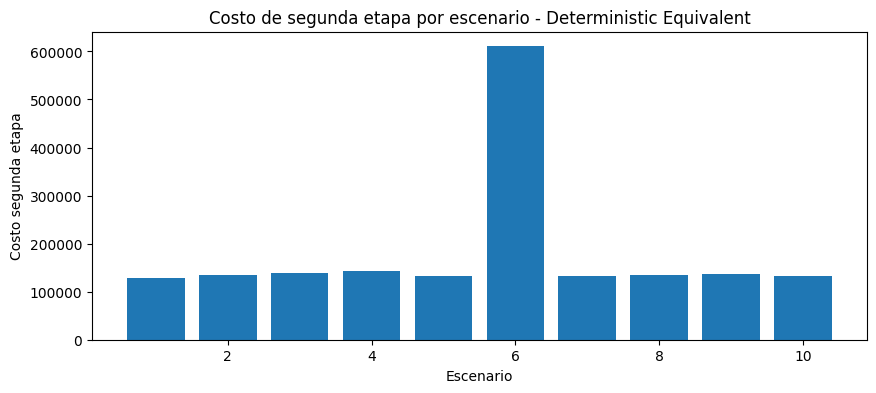

In [19]:
df_costs_plot = df_costs_de.merge(dfp[["omega", "crisis"]], on="omega")

plt.figure(figsize=(10,4))
plt.bar(df_costs_plot["omega"], df_costs_plot["second_stage_cost"])
plt.title("Costo de segunda etapa por escenario - Deterministic Equivalent")
plt.xlabel("Escenario")
plt.ylabel("Costo segunda etapa")
plt.show()

## 2.2. Benders Naive

In [20]:
def solve_second_stage(
    w,
    h_hat,
    base,
    D,
    U_ew,
    c_ew,
    G_iw,
    delta_u=DELTA_U,
    pi=PI,
    verbose=False
):
    """
    Resuelve el subproblema de segunda etapa Q_w(h_hat) para un escenario w.

    El subproblema decide:
    - Flujo por cada arco f_e.
    - Generación usada en cada nodo generador g_i.
    - Demanda no servida delta_i.

    La primera etapa h_hat ya está fija.
    """

    # Extraemos conjuntos y diccionarios de la red base
    nodes_list = base["nodes_list"]
    edges_list = base["edges_list"]
    demand_nodes = base["demand_nodes"]
    gen_nodes = base["gen_nodes"]
    in_arcs = base["in_arcs"]
    out_arcs = base["out_arcs"]

    # Creamos modelo de Gurobi para el subproblema
    sp = gp.Model(f"SP_w{w}")

    # Silenciamos Gurobi si verbose=False
    if not verbose:
        sp.Params.OutputFlag = 0

    # Variables de segunda etapa

    # Flujo en cada arco
    f = sp.addVars(edges_list, lb=0, name="f")

    # Demanda no servida en nodos de demanda
    delta = sp.addVars(demand_nodes, lb=0, name="delta")

    # Generación utilizada en nodos generadores
    g = sp.addVars(gen_nodes, lb=0, name="g")

    # Restricción de capacidad en arcos
    # Si h_hat[e] = 1, la capacidad aumenta en DELTA_U.
    # Si h_hat[e] = 0, se usa la capacidad original del escenario.
    for e in edges_list:
        sp.addConstr(
            f[e] <= U_ew[w, e] * (1 + delta_u * h_hat[e]),
            name=f"cap_e{e}"
        )

    # Restricción de generación máxima
    for i in gen_nodes:
        sp.addConstr(
            g[i] <= G_iw[w, i],
            name=f"gen_i{i}"
        )

    # La demanda no servida no puede superar la demanda
    for i in demand_nodes:
        sp.addConstr(
            delta[i] <= D[w, i],
            name=f"delta_i{i}"
        )

    # Balance de flujo por nodo
    for i in nodes_list:

        inflow = gp.quicksum(f[e] for e in in_arcs[i])
        outflow = gp.quicksum(f[e] for e in out_arcs[i])

        if i in demand_nodes:
            # En nodos de demanda:
            # entrada - salida = demanda satisfecha = demanda total - déficit
            sp.addConstr(
                inflow - outflow == D[w, i] - delta[i],
                name=f"balance_demand_i{i}"
            )

        elif i in gen_nodes:
            # En nodos generadores:
            # entrada - salida = - generación
            sp.addConstr(
                inflow - outflow == -g[i],
                name=f"balance_gen_i{i}"
            )

        else:
            # En nodos de transbordo:
            # entrada = salida
            sp.addConstr(
                inflow - outflow == 0,
                name=f"balance_trans_i{i}"
            )

    # Función objetivo del subproblema
    # Costo operativo + penalización por energía no servida
    operating_cost = gp.quicksum(c_ew[w, e] * f[e] for e in edges_list)
    ens_cost = pi * gp.quicksum(delta[i] for i in demand_nodes)

    sp.setObjective(operating_cost + ens_cost, GRB.MINIMIZE)

    # Resolvemos el subproblema
    sp.optimize()

    # Validamos que Gurobi haya encontrado óptimo
    if sp.Status != GRB.OPTIMAL:
        print(f"Subproblema escenario {w} no óptimo. Status:", sp.Status)
        return None

    # Guardamos resultados relevantes
    result = {
        "objective": sp.ObjVal,
        "operating_cost": sum(c_ew[w, e] * f[e].X for e in edges_list),
        "ens_cost": pi * sum(delta[i].X for i in demand_nodes),
        "flow": {e: f[e].X for e in edges_list},
        "delta": {i: delta[i].X for i in demand_nodes},
        "generation": {i: g[i].X for i in gen_nodes}
    }

    return result

In [21]:
def evaluate_solution(
    h_hat,
    base,
    omegas,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw,
    delta_u=DELTA_U,
    pi=PI,
    verbose=False
):
    """
    Evalúa una solución fija h_hat en todos los escenarios.

    Retorna:
    - costo total esperado,
    - costo de inversión,
    - costo esperado de segunda etapa,
    - costos por escenario.
    """

    edges_list = base["edges_list"]
    H_e = base["H_e"]

    # Calculamos el costo fijo de inversión
    investment_cost = sum(H_e[e] * h_hat[e] for e in edges_list)

    rows = []
    expected_second_stage = 0

    # Evaluamos cada escenario
    for w in omegas:

        sp_res = solve_second_stage(
            w=w,
            h_hat=h_hat,
            base=base,
            D=D,
            U_ew=U_ew,
            c_ew=c_ew,
            G_iw=G_iw,
            delta_u=delta_u,
            pi=pi,
            verbose=verbose
        )

        Q_w = sp_res["objective"]

        # Costo esperado ponderado por probabilidad del escenario
        expected_second_stage += p_omega[w] * Q_w

        rows.append({
            "omega": w,
            "p_omega": p_omega[w],
            "second_stage_cost": Q_w,
            "operating_cost": sp_res["operating_cost"],
            "ens_cost": sp_res["ens_cost"],
            "total_cost_scenario": investment_cost + Q_w,
            "total_deficit": sum(sp_res["delta"].values())
        })

    total_expected_cost = investment_cost + expected_second_stage

    return {
        "total_expected_cost": total_expected_cost,
        "investment_cost": investment_cost,
        "expected_second_stage": expected_second_stage,
        "scenario_costs": pd.DataFrame(rows)
    }

In [23]:
def add_combinatorial_cut(
    model,
    z_var,
    h_vars,
    h_hat,
    Q_hat,
    edges_list,
    name="comb_cut"
):
    """
    Agrega un corte combinatorio de Benders.

    El corte obliga a que:
    - Si h es igual a h_hat, entonces z >= Q_hat.
    - Si h es diferente, el corte se relaja y no afecta demasiado al modelo.

    Este tipo de corte es útil cuando las variables de primera etapa son binarias.
    """

    # Arcos que estaban reforzados en h_hat
    ones = [e for e in edges_list if h_hat[e] >= 0.5]

    # Arcos que no estaban reforzados en h_hat
    zeros = [e for e in edges_list if h_hat[e] < 0.5]

    # Esta expresión vale 1 cuando h es exactamente igual a h_hat.
    # Si h cambia, la expresión baja a 0 o valores negativos.
    expr = 1

    # Penaliza cambios en arcos que antes eran 1
    expr -= gp.quicksum(1 - h_vars[e] for e in ones)

    # Penaliza cambios en arcos que antes eran 0
    expr -= gp.quicksum(h_vars[e] for e in zeros)

    # Corte combinatorio
    model.addConstr(
        z_var >= Q_hat * expr,
        name=name
    )

In [24]:
def solve_benders_naive(
    base,
    omegas,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw,
    delta_u=DELTA_U,
    budget=BUDGET,
    pi=PI,
    max_iter=100,
    tol=1e-4,
    time_limit=None,
    verbose=True
):
    """
    Resuelve el problema estocástico mediante Benders naive.

    El master decide:
    - h_e: si se refuerza o no cada arco.
    - z_w: aproximación del costo de segunda etapa en cada escenario.

    Luego, los subproblemas calculan el costo real Q_w(h).
    """

    start_time = time.time()

    edges_list = base["edges_list"]
    H_e = base["H_e"]

    # Master problem
    master = gp.Model("Benders_Naive")
    master.Params.OutputFlag = 0

    if time_limit is not None:
        master.Params.TimeLimit = time_limit

    # Variables binarias de inversión
    h = master.addVars(edges_list, vtype=GRB.BINARY, name="h")

    # Variables z_w que aproximan el costo de segunda etapa por escenario
    z = master.addVars(omegas, lb=0, name="z")

    # Restricción de presupuesto
    master.addConstr(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) <= budget,
        name="budget"
    )

    # Función objetivo del master:
    # inversión + costo esperado aproximado de segunda etapa
    master.setObjective(
        gp.quicksum(H_e[e] * h[e] for e in edges_list)
        + gp.quicksum(p_omega[w] * z[w] for w in omegas),
        GRB.MINIMIZE
    )

    # Historial para gráficas de convergencia
    LB_history = []
    UB_history = []
    cuts_added_history = []

    UB = float("inf")
    best_h = None
    best_eval = None
    total_cuts = 0

    # Loop de Benders
    for it in range(1, max_iter + 1):

        # Resolvemos el master
        master.optimize()

        if master.Status not in [GRB.OPTIMAL, GRB.TIME_LIMIT]:
            print("Master no óptimo. Status:", master.Status)
            break

        # El objetivo del master es una cota inferior
        LB = master.ObjVal

        # Extraemos solución actual de primera etapa
        h_hat = {e: round(h[e].X) for e in edges_list}

        # Extraemos los valores actuales de z_w
        z_hat = {w: z[w].X for w in omegas}

        scenario_Q = {}
        expected_second_stage = 0
        cuts_this_iter = 0

        # Resolvemos un subproblema por escenario
        for w in omegas:

            sp_res = solve_second_stage(
                w=w,
                h_hat=h_hat,
                base=base,
                D=D,
                U_ew=U_ew,
                c_ew=c_ew,
                G_iw=G_iw,
                delta_u=delta_u,
                pi=pi,
                verbose=False
            )

            Q_w = sp_res["objective"]
            scenario_Q[w] = Q_w
            expected_second_stage += p_omega[w] * Q_w

            # Si z_w es menor al costo real, agregamos corte
            if z_hat[w] < Q_w - tol:
                add_combinatorial_cut(
                    model=master,
                    z_var=z[w],
                    h_vars=h,
                    h_hat=h_hat,
                    Q_hat=Q_w,
                    edges_list=edges_list,
                    name=f"cut_it{it}_w{w}"
                )

                cuts_this_iter += 1
                total_cuts += 1

        # Calculamos costo real de la solución actual
        investment_cost = sum(H_e[e] * h_hat[e] for e in edges_list)
        current_UB = investment_cost + expected_second_stage

        # Actualizamos mejor solución encontrada
        if current_UB < UB:
            UB = current_UB
            best_h = h_hat.copy()
            best_eval = {
                "investment_cost": investment_cost,
                "expected_second_stage": expected_second_stage,
                "scenario_Q": scenario_Q.copy()
            }

        LB_history.append(LB)
        UB_history.append(UB)
        cuts_added_history.append(cuts_this_iter)

        # Gap relativo
        gap = abs(UB - LB) / max(1, abs(UB))

        if verbose:
            print(
                f"Iter {it:03d} | LB={LB:.4f} | UB={UB:.4f} | "
                f"Gap={gap:.6f} | Cortes={cuts_this_iter}"
            )

        # Criterio de parada
        if cuts_this_iter == 0 and gap <= tol:
            if verbose:
                print("Convergencia alcanzada.")
            break

    runtime = time.time() - start_time

    result = {
        "objective": UB,
        "runtime": runtime,
        "best_h": best_h,
        "h_sol": best_h,
        "selected_edges": [e for e in edges_list if best_h[e] > 0.5],
        "num_selected_edges": sum(best_h[e] for e in edges_list),
        "investment_cost": best_eval["investment_cost"],
        "expected_second_stage": best_eval["expected_second_stage"],
        "iterations": it,
        "total_cuts": total_cuts,
        "LB_history": LB_history,
        "UB_history": UB_history,
        "cuts_added_history": cuts_added_history,
        "master_model": master
    }

    return result

In [26]:
# Ejecutamos Benders naive usando los mismos escenarios del DE
benders_results = solve_benders_naive(
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw,
    max_iter=100,
    tol=1e-4,
    verbose=True
)

print("RESULTADOS BENDERS NAIVE")
print("Objetivo Benders:", benders_results["objective"])
print("Tiempo:", benders_results["runtime"])
print("Iteraciones:", benders_results["iterations"])
print("Cortes agregados:", benders_results["total_cuts"])
print("Costo inversión:", benders_results["investment_cost"])
print("Costo esperado segunda etapa:", benders_results["expected_second_stage"])
print("Arcos reforzados:", benders_results["num_selected_edges"])
print("Lista de arcos reforzados:", benders_results["selected_edges"])

print("\nCOMPARACIÓN CONTRA DE")
print("Objetivo DE:", de_results["objective"])
print("Objetivo Benders:", benders_results["objective"])
print("Diferencia absoluta:", abs(de_results["objective"] - benders_results["objective"]))

Iter 001 | LB=0.0000 | UB=190880.8043 | Gap=1.000000 | Cortes=10
Iter 002 | LB=50.0000 | UB=190880.8043 | Gap=0.999738 | Cortes=10
Iter 003 | LB=50.0000 | UB=190880.8043 | Gap=0.999738 | Cortes=10
Iter 004 | LB=50.0000 | UB=190880.8043 | Gap=0.999738 | Cortes=10
Iter 005 | LB=50.0000 | UB=190880.8043 | Gap=0.999738 | Cortes=10
Iter 006 | LB=50.0000 | UB=190880.8043 | Gap=0.999738 | Cortes=10
Iter 007 | LB=50.0000 | UB=190880.8043 | Gap=0.999738 | Cortes=10
Iter 008 | LB=50.0000 | UB=190880.8043 | Gap=0.999738 | Cortes=10
Iter 009 | LB=50.0000 | UB=190880.8043 | Gap=0.999738 | Cortes=10
Iter 010 | LB=50.0000 | UB=190880.8043 | Gap=0.999738 | Cortes=10
Iter 011 | LB=50.0000 | UB=190880.8043 | Gap=0.999738 | Cortes=10
Iter 012 | LB=50.0000 | UB=190880.8043 | Gap=0.999738 | Cortes=10
Iter 013 | LB=50.0000 | UB=188085.3913 | Gap=0.999734 | Cortes=10
Iter 014 | LB=50.0000 | UB=188085.3913 | Gap=0.999734 | Cortes=10
Iter 015 | LB=50.0000 | UB=188085.3913 | Gap=0.999734 | Cortes=10
Iter 016 | 

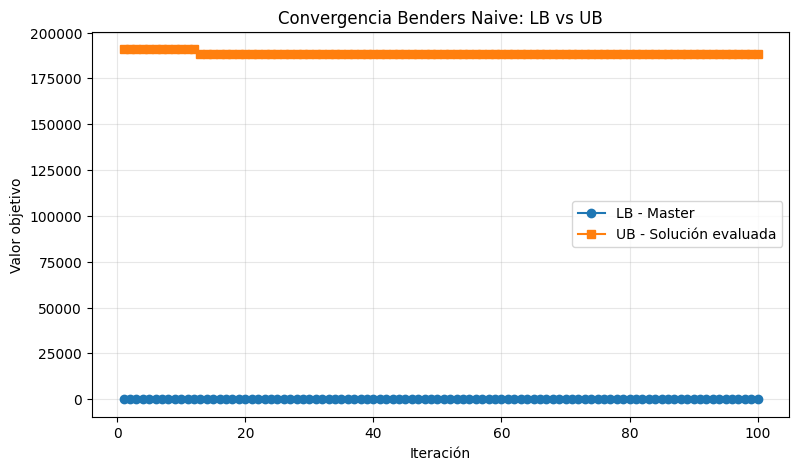

In [28]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(benders_results["LB_history"]) + 1),
    benders_results["LB_history"],
    marker="o",
    label="LB - Master"
)

plt.plot(
    range(1, len(benders_results["UB_history"]) + 1),
    benders_results["UB_history"],
    marker="s",
    label="UB - Solución evaluada"
)

plt.xlabel("Iteración")
plt.ylabel("Valor objetivo")
plt.title("Convergencia Benders Naive: LB vs UB")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2.3. Branch and Cut

In [29]:
def solve_benders_callback(
    base,
    omegas,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw,
    delta_u=DELTA_U,
    budget=BUDGET,
    pi=PI,
    tol=1e-4,
    time_limit=None,
    verbose=True
):
    """
    Resuelve el problema mediante Branch-and-Cut con callbacks.

    En cada solución entera candidata:
    - Se obtiene h_hat.
    - Se resuelven subproblemas.
    - Si z_w subestima Q_w(h_hat), se agrega una lazy constraint.
    """

    start_time = time.time()

    edges_list = base["edges_list"]
    H_e = base["H_e"]

    m = gp.Model("Benders_Callback")

    # Activamos lazy constraints
    m.Params.LazyConstraints = 1

    if not verbose:
        m.Params.OutputFlag = 0

    if time_limit is not None:
        m.Params.TimeLimit = time_limit

    # Variables de primera etapa
    h = m.addVars(edges_list, vtype=GRB.BINARY, name="h")

    # Variables sustitutas para el costo de segunda etapa
    z = m.addVars(omegas, lb=0, name="z")

    # Presupuesto
    m.addConstr(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) <= budget,
        name="budget"
    )

    # Objetivo del master
    m.setObjective(
        gp.quicksum(H_e[e] * h[e] for e in edges_list)
        + gp.quicksum(p_omega[w] * z[w] for w in omegas),
        GRB.MINIMIZE
    )

    # Guardamos información dentro del modelo para usarla en el callback
    m._h = h
    m._z = z
    m._edges_list = edges_list
    m._omegas = omegas
    m._p_omega = p_omega
    m._base = base
    m._D = D
    m._U_ew = U_ew
    m._c_ew = c_ew
    m._G_iw = G_iw
    m._delta_u = delta_u
    m._pi = pi
    m._tol = tol
    m._cuts = 0
    m._incumbent_log = []

    def benders_lazy_callback(model, where):
        """
        Callback que se ejecuta cuando Gurobi encuentra una solución entera.
        """

        if where == GRB.Callback.MIPSOL:

            # Recuperamos solución candidata h
            h_sol = {
                e: round(model.cbGetSolution(model._h[e]))
                for e in model._edges_list
            }

            # Recuperamos valores candidatos de z
            z_sol = {
                w: model.cbGetSolution(model._z[w])
                for w in model._omegas
            }

            cuts_this_solution = 0
            evaluated_second_stage = 0

            # Evaluamos cada subproblema
            for w in model._omegas:

                sp_res = solve_second_stage(
                    w=w,
                    h_hat=h_sol,
                    base=model._base,
                    D=model._D,
                    U_ew=model._U_ew,
                    c_ew=model._c_ew,
                    G_iw=model._G_iw,
                    delta_u=model._delta_u,
                    pi=model._pi,
                    verbose=False
                )

                Q_w = sp_res["objective"]
                evaluated_second_stage += model._p_omega[w] * Q_w

                # Si z_w subestima el costo real, se agrega lazy constraint
                if z_sol[w] < Q_w - model._tol:

                    ones = [e for e in model._edges_list if h_sol[e] >= 0.5]
                    zeros = [e for e in model._edges_list if h_sol[e] < 0.5]

                    expr = 1
                    expr -= gp.quicksum(1 - model._h[e] for e in ones)
                    expr -= gp.quicksum(model._h[e] for e in zeros)

                    model.cbLazy(
                        model._z[w] >= Q_w * expr
                    )

                    model._cuts += 1
                    cuts_this_solution += 1

            investment_cost = sum(
                model._base["H_e"][e] * h_sol[e]
                for e in model._edges_list
            )

            model._incumbent_log.append({
                "investment_cost": investment_cost,
                "expected_second_stage": evaluated_second_stage,
                "evaluated_total_cost": investment_cost + evaluated_second_stage,
                "cuts_added": cuts_this_solution
            })

    # Optimizamos con callback
    m.optimize(benders_lazy_callback)

    runtime = time.time() - start_time

    if m.Status not in [GRB.OPTIMAL, GRB.TIME_LIMIT]:
        print("Modelo callback no óptimo. Status:", m.Status)
        return None

    h_sol = {e: round(h[e].X) for e in edges_list}

    # Evaluamos la solución final para calcular su costo real esperado
    eval_final = evaluate_solution(
        h_hat=h_sol,
        base=base,
        omegas=omegas,
        p_omega=p_omega,
        D=D,
        U_ew=U_ew,
        c_ew=c_ew,
        G_iw=G_iw,
        delta_u=delta_u,
        pi=pi
    )

    result = {
        "objective": eval_final["total_expected_cost"],
        "master_objective": m.ObjVal,
        "runtime": runtime,
        "h_sol": h_sol,
        "best_h": h_sol,
        "selected_edges": [e for e in edges_list if h_sol[e] > 0.5],
        "num_selected_edges": sum(h_sol[e] for e in edges_list),
        "investment_cost": eval_final["investment_cost"],
        "expected_second_stage": eval_final["expected_second_stage"],
        "total_cuts": m._cuts,
        "incumbent_log": pd.DataFrame(m._incumbent_log),
        "model": m
    }

    return result

In [30]:
callback_results = solve_benders_callback(
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw,
    tol=1e-4,
    verbose=True
)

print("RESULTADOS BRANCH-AND-CUT")
print("Objetivo evaluado:", callback_results["objective"])
print("Objetivo master:", callback_results["master_objective"])
print("Tiempo:", callback_results["runtime"])
print("Cortes agregados:", callback_results["total_cuts"])
print("Costo inversión:", callback_results["investment_cost"])
print("Costo esperado segunda etapa:", callback_results["expected_second_stage"])
print("Arcos reforzados:", callback_results["num_selected_edges"])
print("Lista de arcos reforzados:", callback_results["selected_edges"])

Set parameter LazyConstraints to value 1
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 5600U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
LazyConstraints  1

Optimize a model with 1 rows, 189 columns and 179 nonzeros
Model fingerprint: 0xfaf9f4ee
Variable types: 10 continuous, 179 integer (179 binary)
Coefficient statistics:
  Matrix range     [5e+01, 5e+01]
  Objective range  [1e-01, 5e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [3e+03, 3e+03]
Presolve time: 0.01s
Presolved: 1 rows, 189 columns, 179 nonzeros
Variable types: 10 continuous, 179 integer (179 binary)

Root relaxation: objective 5.000000e+01, 1 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

   

GurobiError: Out of memory

## 2.4. Comparación estrategias de solución

In [ ]:
comparison_algorithms = pd.DataFrame([
    {
        "Método": "Deterministic Equivalent",
        "Objetivo": de_results["objective"],
        "Tiempo (s)": de_results["runtime"],
        "Iteraciones / cortes": "-",
        "Arcos reforzados": de_results["num_selected_edges"]
    },
    {
        "Método": "Benders Naive",
        "Objetivo": benders_results["objective"],
        "Tiempo (s)": benders_results["runtime"],
        "Iteraciones / cortes": f'{benders_results["iterations"]} iter / {benders_results["total_cuts"]} cortes',
        "Arcos reforzados": benders_results["num_selected_edges"]
    },
    {
        "Método": "Branch-and-Cut",
        "Objetivo": callback_results["objective"],
        "Tiempo (s)": callback_results["runtime"],
        "Iteraciones / cortes": f'{callback_results["total_cuts"]} cortes',
        "Arcos reforzados": callback_results["num_selected_edges"]
    }
])

comparison_algorithms

## 3. Escalabilidad: SAA y efecto del número de escenarios N

En esta sección se analiza la estabilidad de la solución estocástica cuando cambia el número de escenarios utilizados en la aproximación SAA.

Para cada valor de N se generan varias réplicas independientes. Luego, para cada réplica, se resuelve el problema y se registran:

- valor objetivo,
- tiempo computacional,
- número de arcos reforzados.

Este experimento permite observar si la solución se estabiliza al aumentar N y cómo crece el esfuerzo computacional.

In [ ]:
def run_scalability_experiment(
    N_values=[10, 25, 50],
    M=5,
    method="callback",
    seed_base=123
):
    """
    Ejecuta un experimento SAA.

    Para cada tamaño N:
    - genera M muestras independientes de escenarios,
    - resuelve el problema,
    - guarda objetivo, tiempo y número de arcos reforzados.

    method puede ser:
    - "callback"
    - "naive"
    - "de"
    """

    rows = []

    for N in N_values:
        print(f"\nN = {N}")

        for rep in range(1, M + 1):

            # Semilla diferente para cada réplica
            seed = seed_base + 1000 * N + rep

            # Generamos escenarios
            dfD_N, dfU_N, dfc_N, dfG_N, dfp_N = generate_scenarios_table(
                nodes,
                edges,
                N=N,
                seed=seed
            )

            # Convertimos tablas a diccionarios
            omegas_N, p_omega_N, D_N, U_ew_N, c_ew_N, G_iw_N = build_scenario_data(
                dfD_N,
                dfU_N,
                dfc_N,
                dfG_N,
                dfp_N
            )

            start = time.time()

            # Seleccionamos método de solución
            if method == "callback":
                res = solve_benders_callback(
                    base=base,
                    omegas=omegas_N,
                    p_omega=p_omega_N,
                    D=D_N,
                    U_ew=U_ew_N,
                    c_ew=c_ew_N,
                    G_iw=G_iw_N,
                    verbose=False,
                    time_limit=300
                )

            elif method == "naive":
                res = solve_benders_naive(
                    base=base,
                    omegas=omegas_N,
                    p_omega=p_omega_N,
                    D=D_N,
                    U_ew=U_ew_N,
                    c_ew=c_ew_N,
                    G_iw=G_iw_N,
                    verbose=False,
                    max_iter=100,
                    time_limit=300
                )

            elif method == "de":
                res = solve_deterministic_equivalent(
                    base=base,
                    omegas=omegas_N,
                    p_omega=p_omega_N,
                    D=D_N,
                    U_ew=U_ew_N,
                    c_ew=c_ew_N,
                    G_iw=G_iw_N,
                    verbose=False,
                    time_limit=300
                )

            else:
                raise ValueError("method debe ser: 'callback', 'naive' o 'de'")

            runtime = time.time() - start

            rows.append({
                "N": N,
                "replica": rep,
                "method": method,
                "objective": res["objective"],
                "runtime": runtime,
                "num_selected_edges": res["num_selected_edges"]
            })

            print(
                f"Rep {rep}/{M} | Obj={res['objective']:.2f} | "
                f"Tiempo={runtime:.2f}s | Arcos={res['num_selected_edges']}"
            )

    return pd.DataFrame(rows)